In [240]:
from neural_priors.utils.data import Subject
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
import os.path as op

bids_folder = '/data/ds-neuralpriors'

In [242]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.odr import Model, Data, ODR

def linear_model(beta, x):
    """ Defines a linear model y = m*x + b for ODR fitting """
    return beta[0] * x + beta[1]

def total_least_squares_odr(X, Y):
    """ Fits a Total Least Squares regression using scipy.odr """
    # Initial guess for slope and intercept (using OLS as a rough estimate)
    initial_guess = np.polyfit(X, Y, 1)

    # Set up the ODR model
    model = Model(linear_model)
    data = Data(X, Y)
    odr = ODR(data, model, beta0=initial_guess)

    # Run the regression
    output = odr.run()

    # Extract slope and intercept
    slope, intercept = output.beta
    return slope, intercept

# Example data (noisy)
np.random.seed(42)
X = np.linspace(0, 10, 20)
Y = 2.5 * X + np.random.normal(scale=2, size=X.shape)  # True slope = 2.5

# Compute TLS using scipy.odr


In [251]:
roi = 'NPCr'
pars = pd.read_csv(op.join(bids_folder, 'derivatives', 'summary_encoding_models.alpha.smoothed', f'group_roi-{roi}_parameters.tsv'), sep='\t', header=[0, 1], index_col=[0,1,2])
pars = pars.xs(13, 0, level='model_label')
print(pars.shape)
pars = pars[pars[('cvr2', 'nan')] > 0.001]


mu = pars['mu']
mu['cvr2'] = pars['cvr2']


# odr = mu.groupby(['subject_id']).apply(lambda x: pd.Series(total_least_squares_odr(x['narrow'], x['wide']), index=['slope', 'intercept']))


def compute_odr_with_intersection(x):
    slope, intercept = total_least_squares_odr(x['narrow'], x['wide'])
    intersection = intercept / (1 - slope) if slope != 1 else np.nan
    return pd.Series({'slope': slope, 'intercept': intercept, 'intersection': intersection})

odr = mu.groupby(['subject_id']).apply(compute_odr_with_intersection)


(30533, 12)


/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_58058/2465612230.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mu['cvr2'] = pars['cvr2']


In [252]:
odr

,slope,intercept,intersection
subject_id,,,
1,2.837859,-18.248915,9.929440
2,1.361463,-0.978470,2.706974
3,1.143317,-1.238296,8.640254
4,1.631314,-7.520592,11.912600
5,1.317931,-2.515240,7.911278
6,2.050317,-8.378409,7.977028
7,2.430485,-12.725047,8.895617
8,2.480752,-17.806078,12.025020
9,1.630790,-7.424356,11.769938


count    39.000000
mean      2.146048
std       0.835921
min       1.143317
25%       1.569558
50%       1.952761
75%       2.503025
max       5.273492
Name: slope, dtype: float64

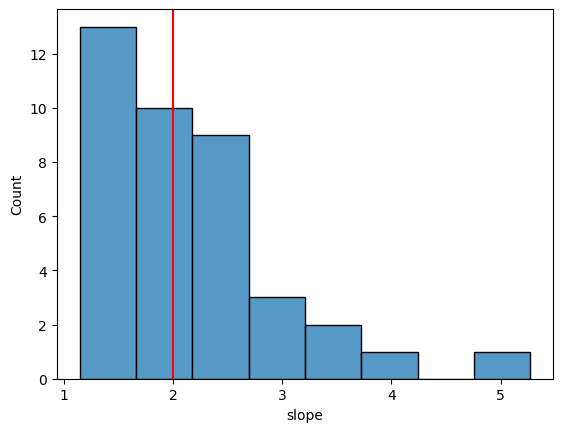

In [253]:
sns.histplot(odr['slope'])
plt.axvline(2.0, color='r')

odr['slope'].describe()

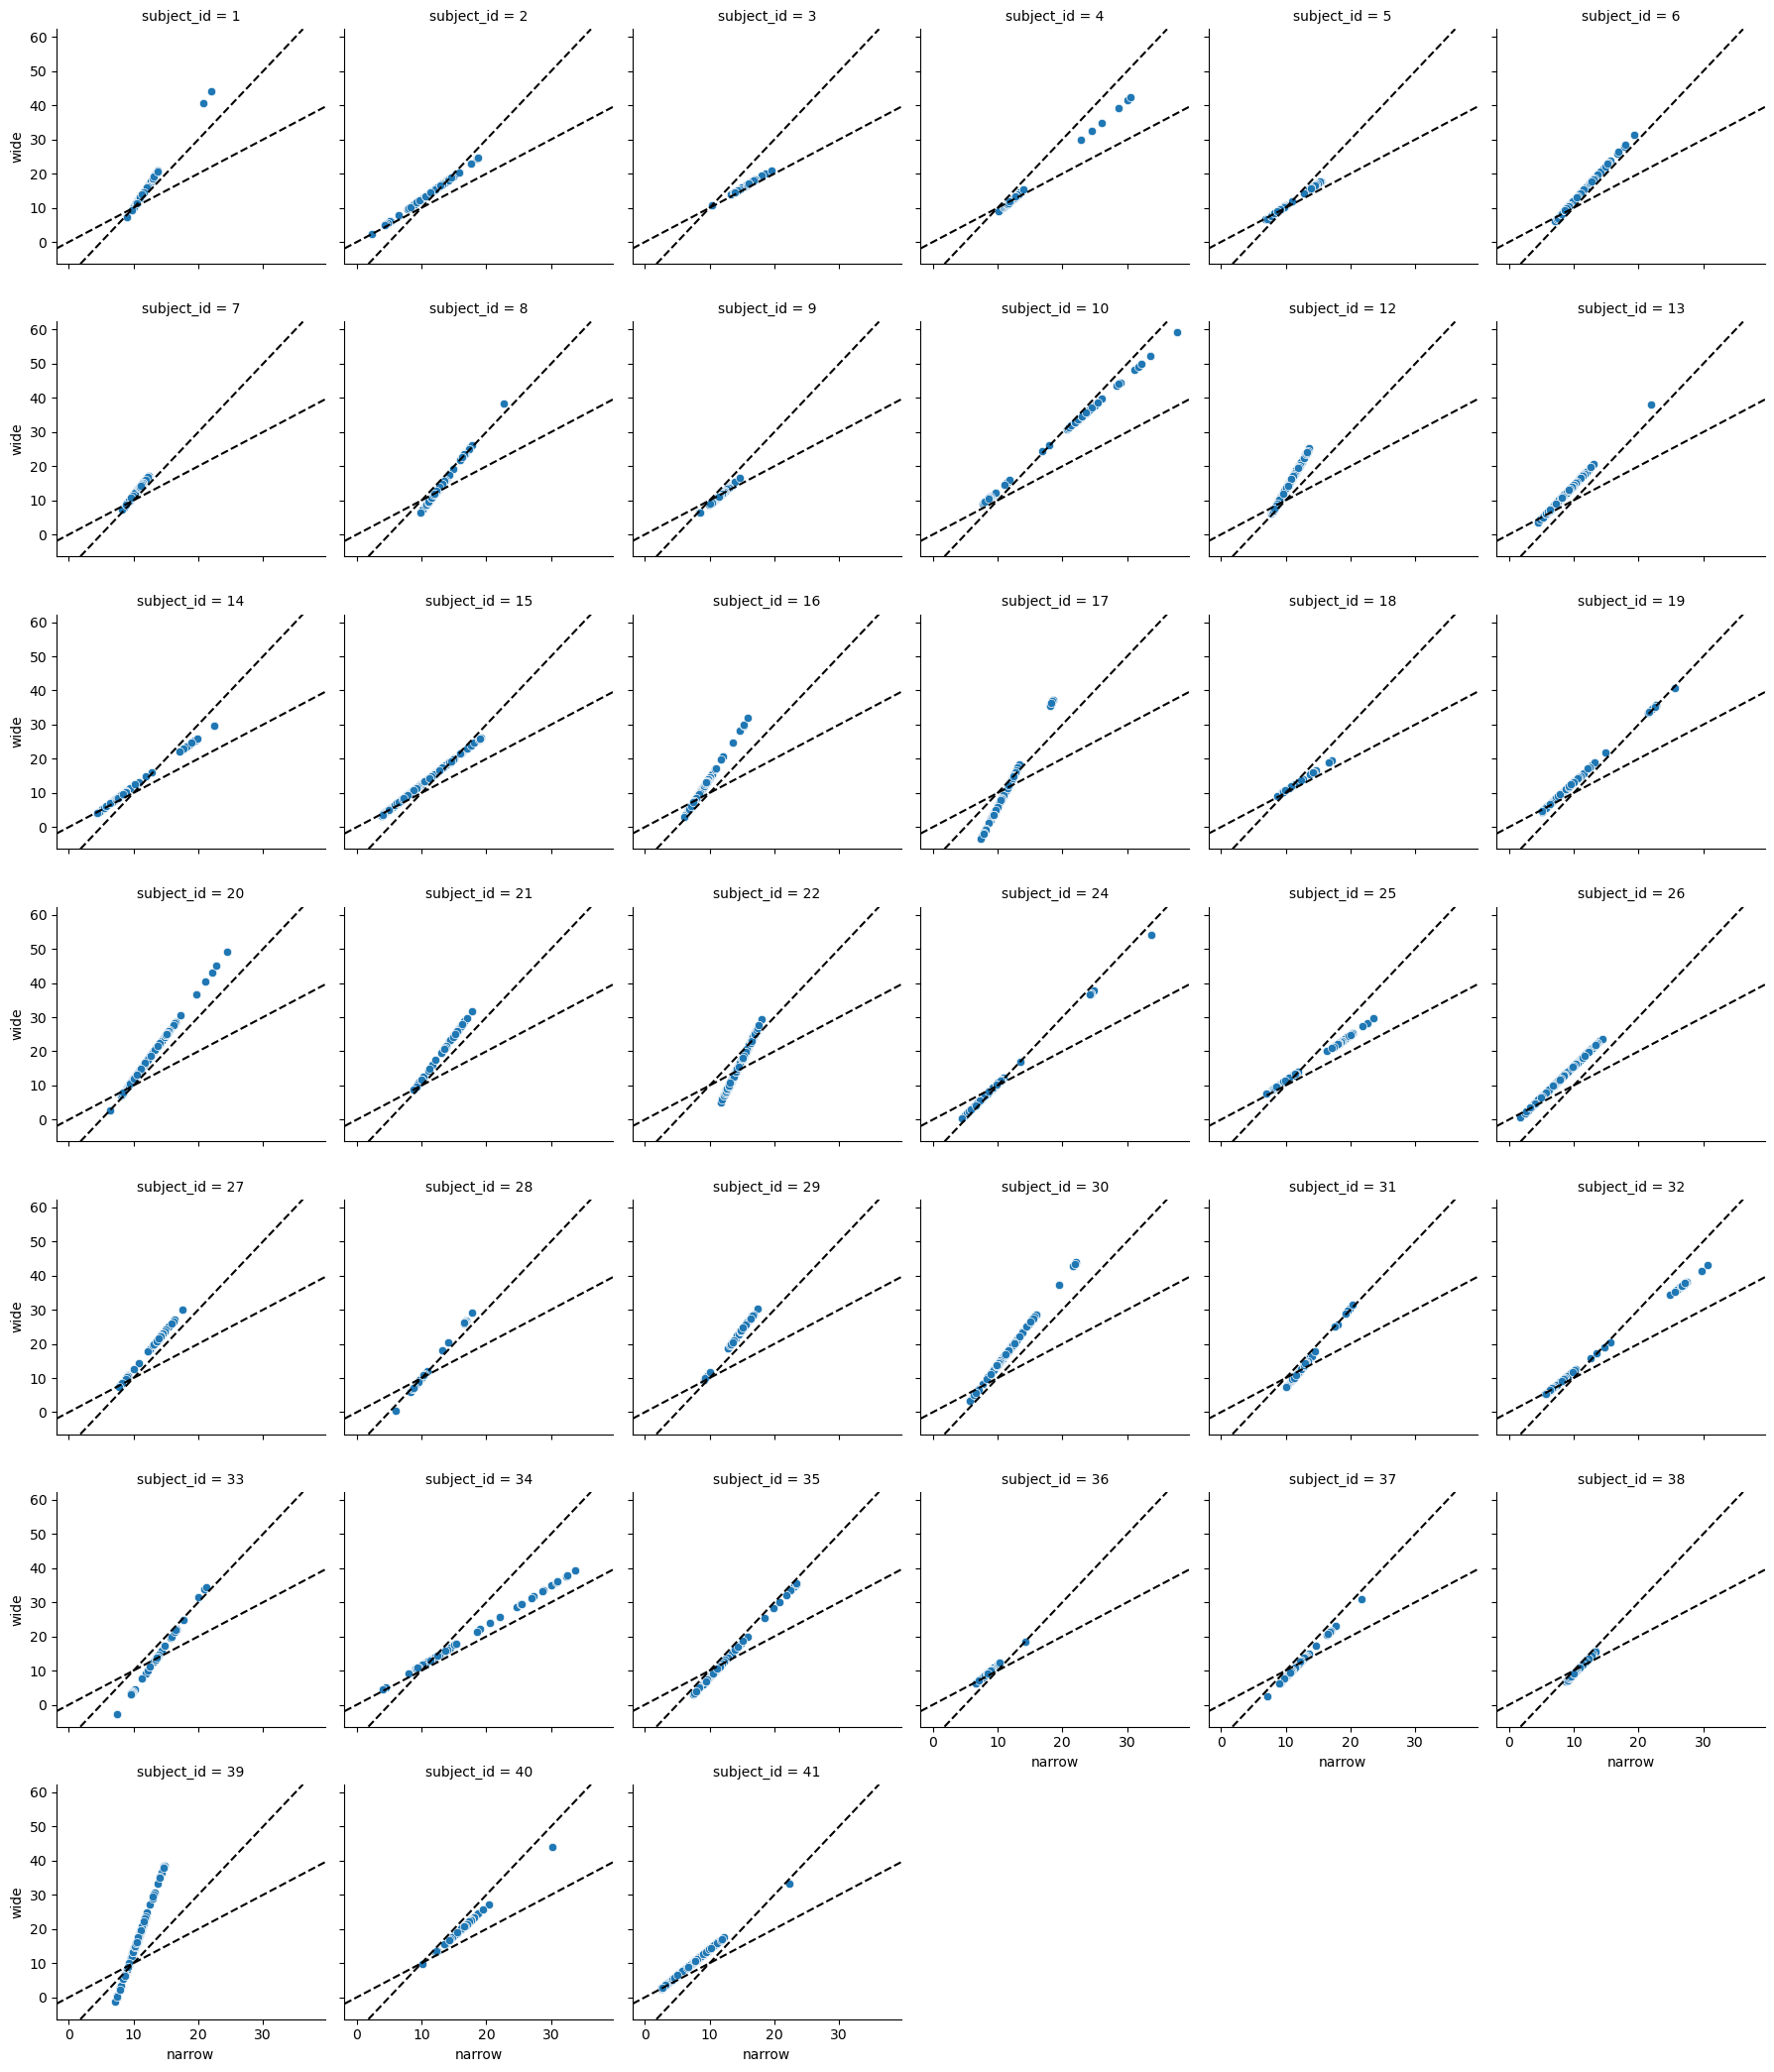

In [254]:
g = sns.FacetGrid(data=mu.reset_index(), col='subject_id', col_wrap=6)

g.map(sns.scatterplot, 'narrow', 'wide')


# Plot identity line
# Scatter plot
g.map(sns.scatterplot, 'narrow', 'wide')

# Add identity line (diagonal)

# Add identity line
g.map(lambda **kwargs: plt.axline((0, 0), slope=1, color='k', linestyle='--'))
g.map(lambda **kwargs: plt.axline((10, 10), slope=2, color='k', linestyle='--'))


[DEBUG] Plotting subject 1: slope=2.84, intercept=-18.25, intersection=9.93, ax: Axes(0.0344599,0.870881;0.15034x0.11277)
[DEBUG] Plotting subject 2: slope=1.36, intercept=-0.98, intersection=2.71, ax: Axes(0.195833,0.870881;0.15034x0.11277)
[DEBUG] Plotting subject 3: slope=1.14, intercept=-1.24, intersection=8.64, ax: Axes(0.357207,0.870881;0.15034x0.11277)
[DEBUG] Plotting subject 4: slope=1.63, intercept=-7.52, intersection=11.91, ax: Axes(0.51858,0.870881;0.15034x0.11277)
[DEBUG] Plotting subject 5: slope=1.32, intercept=-2.52, intersection=7.91, ax: Axes(0.679954,0.870881;0.15034x0.11277)
[DEBUG] Plotting subject 6: slope=2.05, intercept=-8.38, intersection=7.98, ax: Axes(0.841327,0.870881;0.15034x0.11277)
[DEBUG] Plotting subject 7: slope=2.43, intercept=-12.73, intersection=8.90, ax: Axes(0.0344599,0.730359;0.15034x0.11277)
[DEBUG] Plotting subject 8: slope=2.48, intercept=-17.81, intersection=12.03, ax: Axes(0.195833,0.730359;0.15034x0.11277)
[DEBUG] Plotting subject 9: slope=

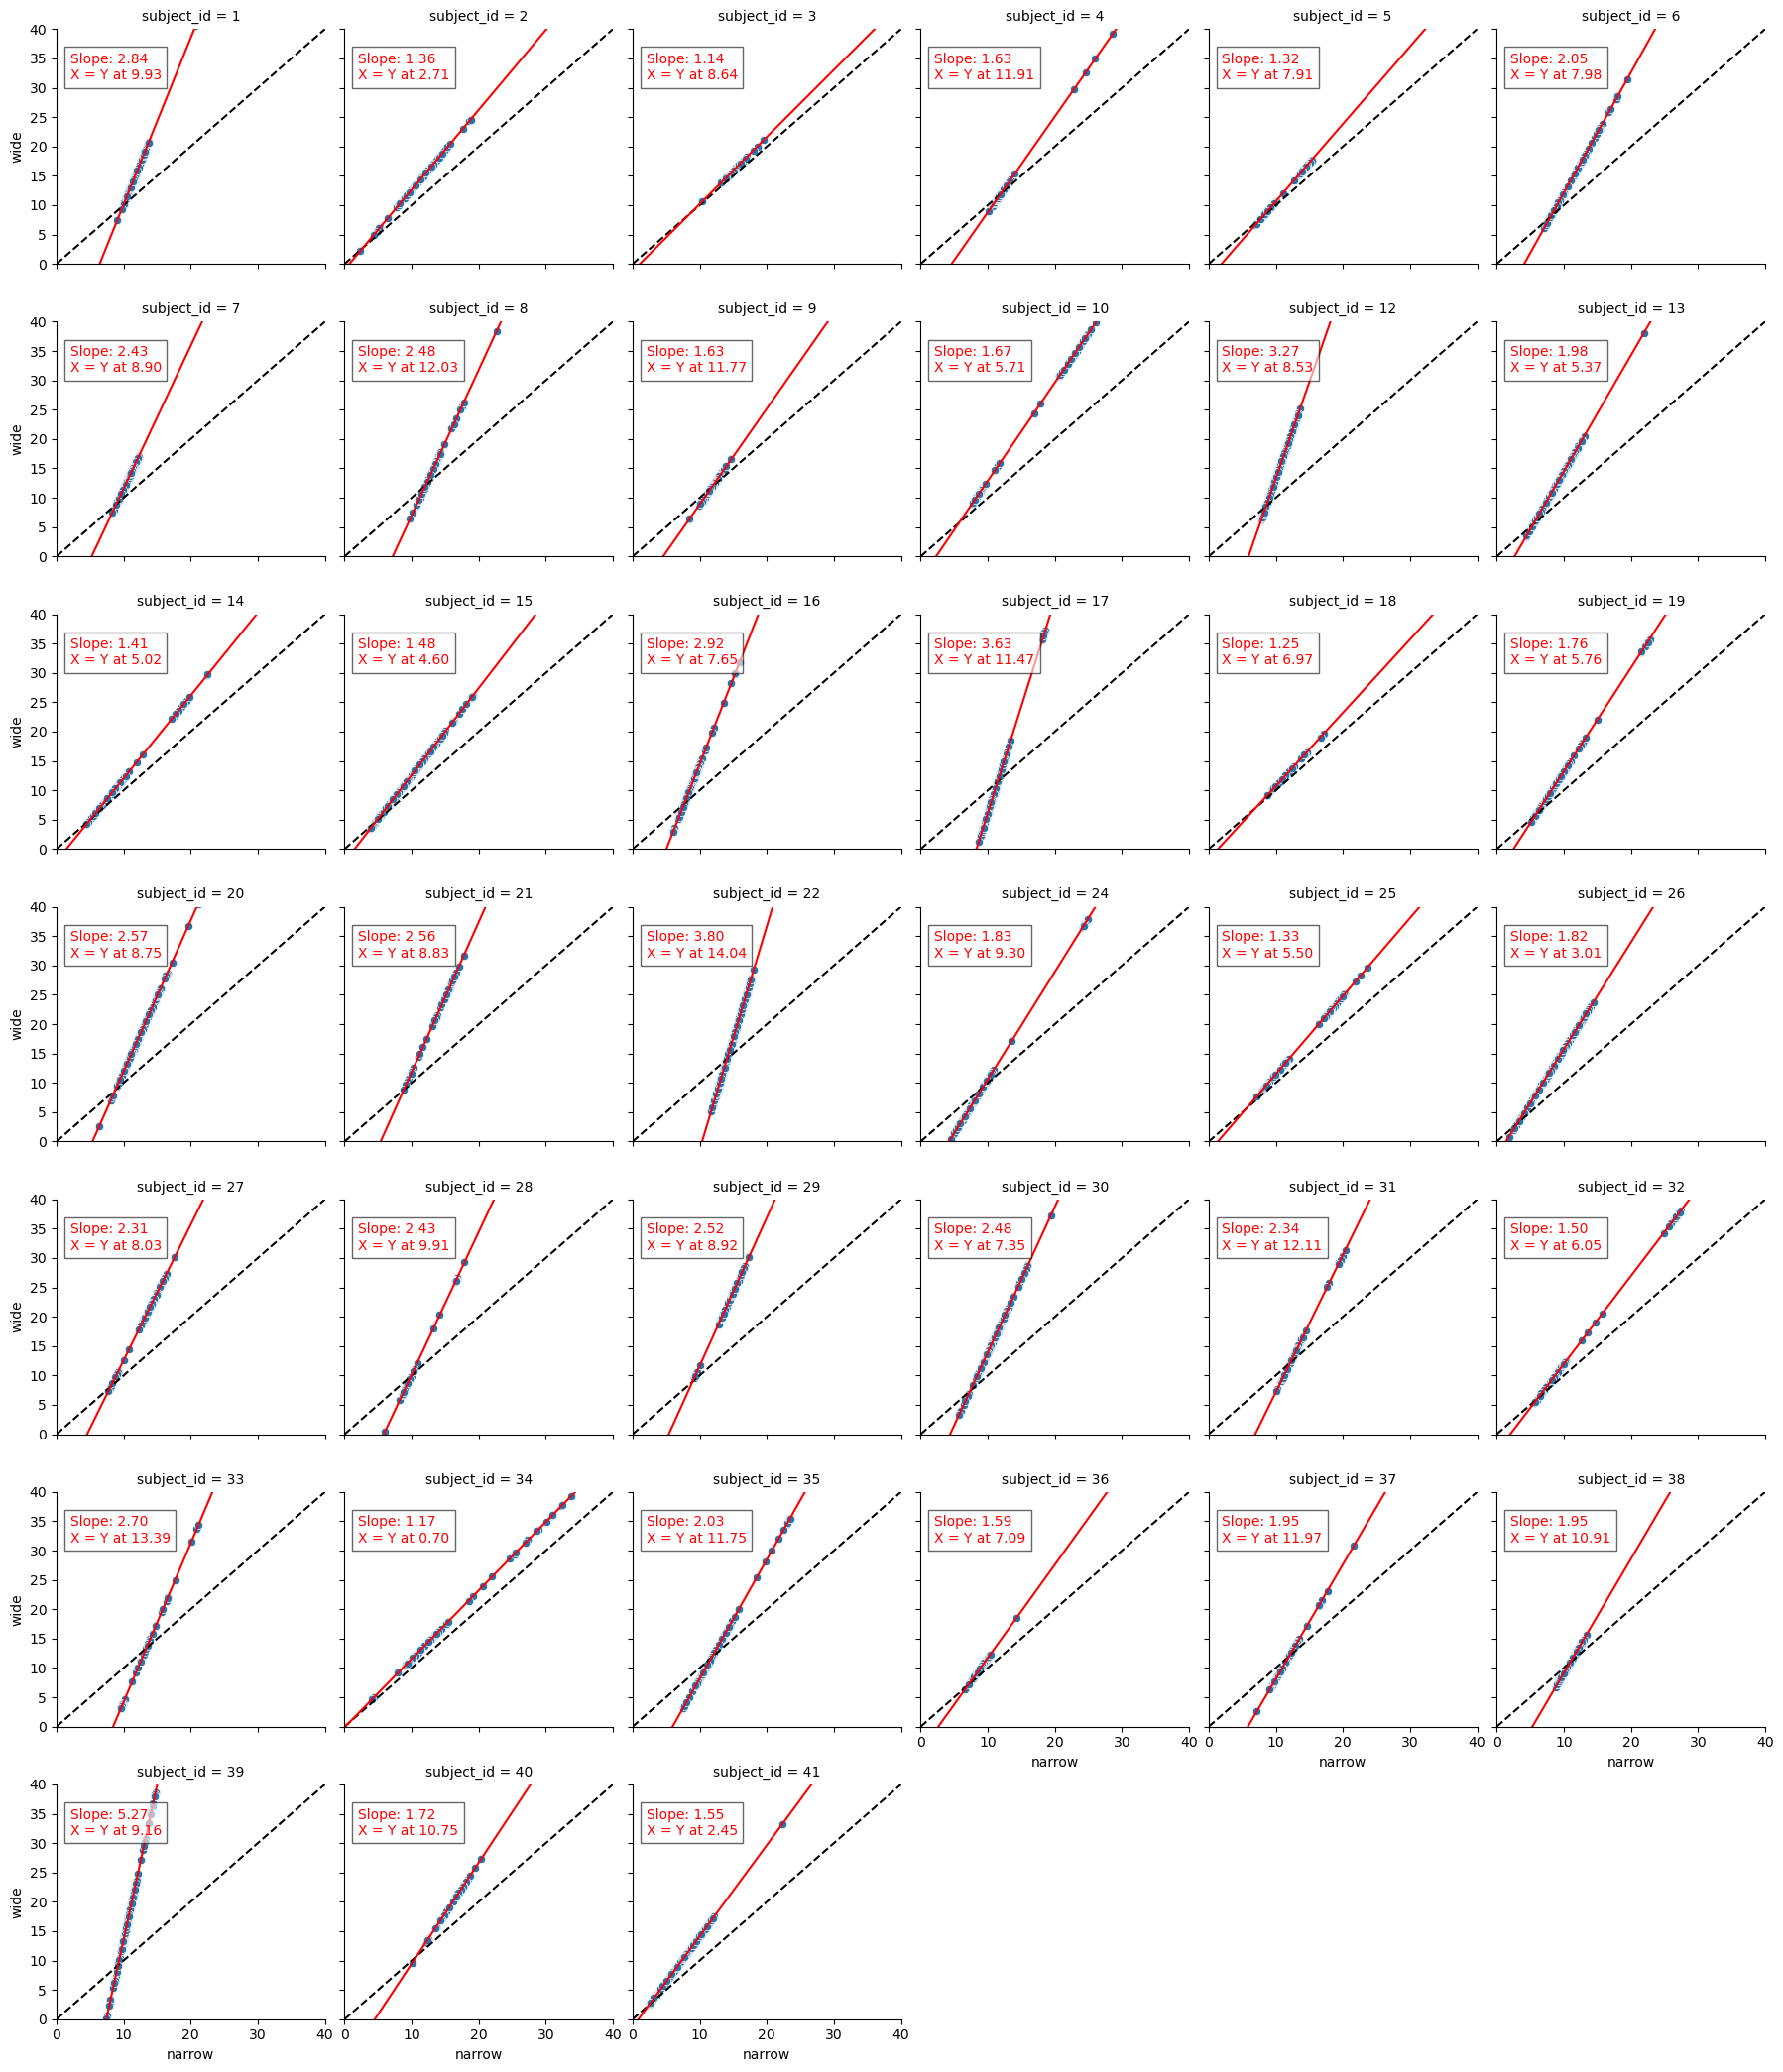

In [255]:
import seaborn as sns
import matplotlib.pyplot as plt

# Compute ODR regression per subject
def compute_odr_with_intersection(x):
    slope, intercept = total_least_squares_odr(x['narrow'], x['wide'])
    intersection = intercept / (1 - slope) if slope != 1 else np.nan
    return pd.Series({'slope': slope, 'intercept': intercept, 'intersection': intersection})

odr = mu.groupby(['subject_id']).apply(compute_odr_with_intersection).reset_index()

# Create FacetGrid
g = sns.FacetGrid(data=mu.reset_index(), col='subject_id', col_wrap=6)

# Scatter plot
g.map(sns.scatterplot, 'narrow', 'wide')

# Add identity line (y = x) ONCE per subplot
for ax in g.axes.flat:
    ax.axline((0, 0), slope=1, color='k', linestyle='--')

# Function to plot ODR regression line and annotate slope + intersection
def plot_odr_line_and_annotate(ax, data):
    """ Plots ODR regression line and annotation for a given subject. """
    if isinstance(data, tuple):  
        data = data[0]  # Extract actual DataFrame from tuple

    if not isinstance(data, pd.DataFrame) or data.empty:
        return  # Skip if facet data is missing or empty

    subject_id = data['subject_id'].iloc[0]  # Extract subject ID
    row = odr.loc[odr['subject_id'] == subject_id]

    if row.empty:
        print(f"[DEBUG] No ODR data for subject {subject_id}, skipping.")
        return  # Skip if no regression data for this subject

    slope, intercept, intersection = row[['slope', 'intercept', 'intersection']].values[0]

    print(f"[DEBUG] Plotting subject {subject_id}: slope={slope:.2f}, intercept={intercept:.2f}, intersection={intersection:.2f}, ax: {ax}")

    # Draw the ODR regression line
    ax.axline((0, intercept), slope=slope, color='r', linestyle='-')

    # Annotate slope and intersection
    text_x = ax.get_xlim()[0] + 0.05 * (ax.get_xlim()[1] - ax.get_xlim()[0])  
    text_y = ax.get_ylim()[1] - 0.1 * (ax.get_ylim()[1] - ax.get_ylim()[0])  

    ax.text(text_x, text_y, f"Slope: {slope:.2f}\nX = Y at {intersection:.2f}",
            fontsize=10, color='red', ha='left', va='top', bbox=dict(facecolor='white', alpha=0.6))

g.set(xlim=(0, 40), ylim=(0, 40))  # Set axis limits

# Correctly match subjects to axes
for ax, facet in zip(g.axes.flat, g.facet_data()):  
    data = facet[1]  # Extract DataFrame from tuple
    plot_odr_line_and_annotate(ax, data)


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Compute ODR regression per subject
def compute_odr_with_intersection(x):
    slope, intercept = total_least_squares_odr(x['narrow'], x['wide'])
    intersection = intercept / (1 - slope) if slope != 1 else np.nan
    return pd.Series({'slope': slope, 'intercept': intercept, 'intersection': intersection})

odr = mu.groupby(['subject_id']).apply(compute_odr_with_intersection).reset_index()

# Create FacetGrid
g = sns.FacetGrid(data=mu.reset_index(), col='subject_id', col_wrap=6)

# Scatter plot
g.map(sns.scatterplot, 'narrow', 'wide')

# Add identity line (y = x) ONCE per subplot
for ax in g.axes.flat:
    ax.axline((0, 0), slope=1, color='k', linestyle='--')

# Function to plot ODR regression line and annotate slope + intersection
def plot_odr_line_and_annotate(ax, data):
    """ Plots ODR regression line and annotation for a given subject. """
    if isinstance(data, tuple):  
        data = data[0]  # Extract actual DataFrame from tuple

    if not isinstance(data, pd.DataFrame) or data.empty:
        return  # Skip if facet data is missing or empty

    subject_id = data['subject_id'].iloc[0]  # Extract subject ID
    row = odr.loc[odr['subject_id'] == subject_id]

    if row.empty:
        print(f"[DEBUG] No ODR data for subject {subject_id}, skipping.")
        return  # Skip if no regression data for this subject

    slope, intercept, intersection = row[['slope', 'intercept', 'intersection']].values[0]

    print(f"[DEBUG] Plotting subject {subject_id}: slope={slope:.2f}, intercept={intercept:.2f}, intersection={intersection:.2f}, ax: {ax}")

    # Draw the ODR regression line
    ax.axline((0, intercept), slope=slope, color='r', linestyle='-')

    # Annotate slope and intersection
    text_x = ax.get_xlim()[0] + 0.05 * (ax.get_xlim()[1] - ax.get_xlim()[0])  
    text_y = ax.get_ylim()[1] - 0.1 * (ax.get_ylim()[1] - ax.get_ylim()[0])  

    ax.text(text_x, text_y, f"Slope: {slope:.2f}\nX = Y at {intersection:.2f}",
            fontsize=10, color='red', ha='left', va='top', bbox=dict(facecolor='white', alpha=0.6))

g.set(xlim=(0, 40), ylim=(0, 40))  # Set axis limits

# Correctly match subjects to axes
for ax, facet in zip(g.axes.flat, g.facet_data()):  
    data = facet[1]  # Extract DataFrame from tuple
    plot_odr_line_and_annotate(ax, data)


<Axes: xlabel='slope', ylabel='Count'>

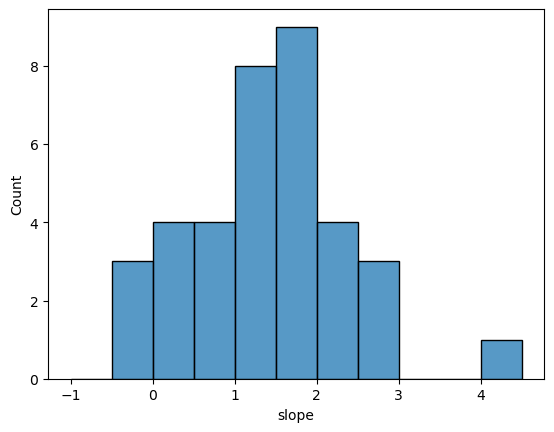

In [238]:
sns.histplot(odr['slope'], bins=np.arange(-1, 5, .5))

# plt.xlim(0, 20)

(0.0, 20.0)

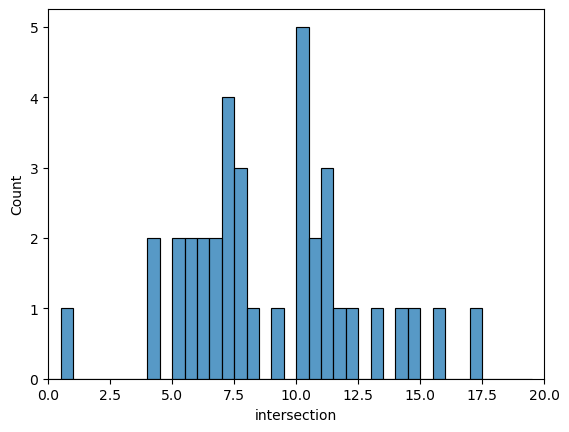

In [235]:
sns.histplot(odr['intersection'], bins=np.arange(0, 20, .5))

plt.xlim(0, 20)

In [ ]:
g.facet_datas

<bound method FacetGrid.facet_data of <seaborn.axisgrid.FacetGrid object at 0x304cff490>>

In [222]:
g.col_names

[1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 12,
 13,
 14,
 15,
 16,
 17,
 18,
 19,
 20,
 21,
 22,
 24,
 25,
 26,
 27,
 28,
 29,
 30,
 31,
 32,
 33,
 34,
 35,
 36,
 37,
 38,
 39,
 40,
 41]

In [218]:
for ix, d in g.facet_data():
    print(ix)

(0, 0, 0)
(0, 1, 0)
(0, 2, 0)
(0, 3, 0)
(0, 4, 0)
(0, 5, 0)
(0, 6, 0)
(0, 7, 0)
(0, 8, 0)
(0, 9, 0)
(0, 10, 0)
(0, 11, 0)
(0, 12, 0)
(0, 13, 0)
(0, 14, 0)
(0, 15, 0)
(0, 16, 0)
(0, 17, 0)
(0, 18, 0)
(0, 19, 0)
(0, 20, 0)
(0, 21, 0)
(0, 22, 0)
(0, 23, 0)
(0, 24, 0)
(0, 25, 0)
(0, 26, 0)
(0, 27, 0)
(0, 28, 0)
(0, 29, 0)
(0, 30, 0)
(0, 31, 0)
(0, 32, 0)
(0, 33, 0)
(0, 34, 0)
(0, 35, 0)
(0, 36, 0)
(0, 37, 0)
(0, 38, 0)


In [214]:
g.axes.flat

In [213]:
facet[0] 

(0, 38, 0)

In [211]:
data

(0, 0, 0)

In [202]:
ax

<Axes: title={'center': 'subject_id = 41'}, xlabel='narrow'>

In [ ]:
pars = sub.get_prf_parameters_volume(sensory_space='alpha', smoothed=True, model_label=6, roi='NPCr')




mu = pars['mu']
mu['r2'] = pars[('cvr2', None)]
mu = mu[mu['r2'] > 0.0]

/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_58058/4057306097.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mu['r2'] = pars[('cvr2', None)]


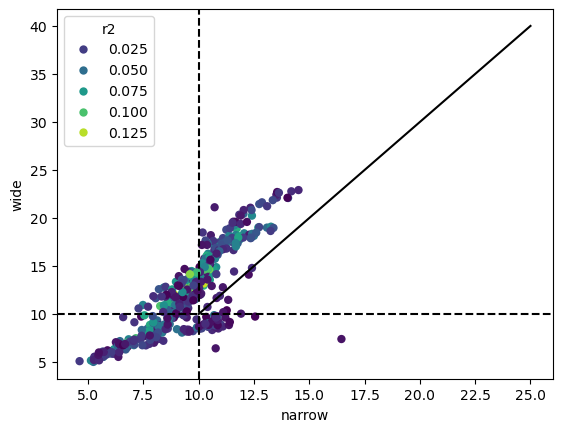

In [105]:
sns.scatterplot(x='narrow', y='wide', data=mu, hue='r2', palette='viridis', edgecolor='none')

# plt.plot([4, 20], [4,20], c='k')
plt.plot([10, 25], [10,40], c='k')

plt.axhline(10.0, c='k',ls='--')
plt.axvline(10.0, c='k',ls='--')

In [106]:
import numpy as np
import matplotlib.pyplot as plt

def total_least_squares(X, Y):
    # Center the data
    X_mean, Y_mean = np.mean(X), np.mean(Y)
    X_centered, Y_centered = X - X_mean, Y - Y_mean

    # Create the data matrix
    A = np.column_stack((X_centered, Y_centered))

    # Perform SVD
    U, S, Vt = np.linalg.svd(A)

    # The slope is given by the smallest singular vector
    v = Vt[-1]  # Last row of V^T corresponds to the smallest singular value
    slope = -v[0] / v[1]  # dy/dx (negative because the vector is perpendicular)

    # Intercept
    intercept = Y_mean - slope * X_mean

    return slope, intercept


In [107]:
total_least_squares(mu['narrow'], mu['wide'])

(2.48155, -11.520263)